# `kNNpy.Auxiliary.TPCF.3DTPCF_Tracer-Field` Tutorial: Clustering in a 3D box using cross-correlation between discrete and field data with the two-point correlation function.

**Author**: Anargha Mondal\
**Date**: 18 May 2026\
**kNNpy version**: 0.0.1

#### This notebook presents a simple guide on how to use the `3DTPCF_Tracer-Field` Auxiliary module to calculate the two-point cross-correlation between discrete and field data. The basic functionalities of the module are illustrated using realistic cosmological N-body simulations, taken from [QUIJOTE simulations](https://quijote-simulations.readthedocs.io/en/latest/). A detailed API [documentation](https://kitnenikatnivasi.github.io/kNNpy_documentation_html/kNNpy/Auxiliary/TPCF/3DTPCF_Tracer-Field.html) and source code for the module is available on the `kNNpy` [website](https://kitnenikatnivasi.github.io/).

<!--TABLE OF CONTENTS-->
# Contents:
- [Imports and Setup](#Imports-and-Setup)
- [Tracer-field cross-correlations](#Tracer-field-cross-correlations)
  - [Loading the required datasets](#Loading-the-required-datasets)
  - [Making the successive smoothing filters in Fourier space and the grid in real space](#Making-the-successive-smoothing-filters-in-Fourier-space-and-the-grid-in-real-space)
- [Comparison](#Comparison)
    

# Imports and Setup

#### Let's start by importing the required Python libraries. These should already be present in the `kNNpy_env` virtual environment created during the [installation](https://kitnenikatnivasi.github.io/install.html), so you should be able to import them without any issues.

In [1]:
#Importing external libraries

import numpy as np
import readgadget
import readfof

from matplotlib import pyplot as plt, ticker as mticker
import matplotlib.colors as colors

import os
import sys

import warnings
import plotting_library as PL
from pylab import *
from matplotlib.colors import LogNorm
#We prefer turning off the annoying warnings thrown by Python. Comment out the line below if you prefer to view the warnings as they arise.
warnings.filterwarnings('ignore')

import MAS_library as MASL

#Importing the kNNpy modules that will be used in this tutorial

#Necessary for relative imports (see https://stackoverflow.com/questions/34478398/import-local-function-from-a-module-housed-in-another-directory-with-relative-im)
module_path = os.path.abspath(os.path.join('../'))           # '../' is needed because the parent directory is one directories upstream of the tutorials directory
if module_path not in sys.path:
    sys.path.append(module_path)

from kNNpy import HelperFunctions as hf 
from kNNpy.Auxiliary.TPCF import TracerField3D as tpcf         

#### We define our `matplotlib` plotting preferences below; you can change them to your liking. Remember to set `ustex==False` if you do not have $\LaTeX$ installed. 

In [2]:
#Matplotlib settings

plt.rcParams['font.family'] = 'serif'
plt.rc('text', usetex=True)
plt.rcParams.update({'font.size': 18})
plt.rcParams["axes.linewidth"] = 2*0.8
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["xtick.major.width"] = 2*0.8
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams["ytick.major.width"] = 2*0.8
plt.rcParams["xtick.major.size"] = 2*3.5
plt.rcParams["ytick.major.size"] = 2*3.5
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.width"] = 2*0.6
plt.rcParams["ytick.minor.width"] = 2*0.6
plt.rcParams["xtick.minor.size"] = 2*2
plt.rcParams["ytick.minor.size"] = 2*2

DefaultColorCycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
BrightColors = ['cyan', 'yellow', 'lime', 'pink', '#E0B0FF']

# Tracer-field cross-correlations

Point-field or tracer-field cross-correlations are used, for example, in studies of galaxy-galaxy lensing, where galaxy positions are correlated with the shear field. Thus they are of practical importance for upcoming weak lensing surveys for large scale structure.

We use the QUIJOTE datasets 

### Loading the required datasets

In [ ]:
box_size = 1000.0 #Mpc/h
#Number of realisations
n_reals = 5
grid=256

# Grid resolution (used by the shell filters below)
grid_cell_size = box_size / grid  # Mpc/h

n_bins = 50
# Radii (not bin edges) at which xi(r) is evaluated
bins = np.linspace(grid_cell_size, 50.0, n_bins) #Mpc/h
# Shell thickness: must be comparable to >= grid_cell_size to avoid empty shells
thickness = grid_cell_size
threads=8

### Making the successive smoothing filters in Fourier space and the grid in real space

In [4]:
# Keep these consistent if you change box_size/grid and re-run only this cell
grid_cell_size = box_size / grid
thickness = grid_cell_size

coords = (np.arange(grid) - grid // 2) * grid_cell_size
r_grid = hf.compute_r_grid(coords, grid)
W_k_list = hf.make_W_k_list(bins, thickness, grid, r_grid, threads)

### Testing kNNpy.Auxiliary.TPCF.TracerField3D with random points $\times$ field read from snapshots

In [21]:
n_realis =5

In [22]:
pos_array=[]
for i in range(n_realis):
    snapshot = f'/data/kNNpy/Tutorials/Tutorial_data/2PCF_3D/Snaps/fiducial_LR/{i}/snapdir_004/snap_004'
    pos = readgadget.read_block(snapshot, 'POS ', [1])/1e3
    pos_array.append(pos)

pos_array = np.array(pos_array)

In [30]:
print(pos_array.shape)

(5, 16777216, 3)


In [23]:
do_RSD = False
verbose= True
axis=0
MAS= 'CIC'


In [28]:
results_list=[]
for i in range(n_realis):
    snapshot = f'/data/kNNpy/Tutorials/Tutorial_data/2PCF_3D/Snaps/fiducial_LR/{i}/snapdir_004/snap_004'
    delta = MASL.density_field_gadget(snapshot, [1], grid, MAS, do_RSD, axis, verbose)
    delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0
    results = tpcf.CrossCorr2pt(bins, pos_array[i], delta, box_size, threads, W_k_list)
    results_list.append(results)

results_array = np.array(results_list)
results_mean = np.mean(results_array, axis=0)
results_std = np.std(results_array, axis=0)


Computing density field of particles [1]
1.67772160e+07 should be equal to
1.67772160e+07
Time taken = 0.42 seconds

Computing density field of particles [1]
1.67772160e+07 should be equal to
1.67772160e+07
Time taken = 0.45 seconds

Computing density field of particles [1]
1.67772160e+07 should be equal to
1.67772160e+07
Time taken = 0.45 seconds

Computing density field of particles [1]
1.67772160e+07 should be equal to
1.67772160e+07
Time taken = 0.43 seconds

Computing density field of particles [1]
1.67772160e+07 should be equal to
1.67772160e+07
Time taken = 0.44 seconds


### Testing kNNpy.Auxiliary.TPCF.TracerField3D with random points $\times$ field read from snapshots

In [31]:
random_pos_array=[]
seed=42
np.random.seed(seed)
for i in range(n_realis):
    random_pos = np.random.uniform(0, box_size, size=(pos_array.shape[1], 3))
    random_pos_array.append(random_pos)
    seed+=1

In [32]:
random_results_list=[]
for i in range(n_realis):
    snapshot = f'/data/kNNpy/Tutorials/Tutorial_data/2PCF_3D/Snaps/fiducial_LR/{i}/snapdir_004/snap_004'
    delta = MASL.density_field_gadget(snapshot, [1], grid, MAS, do_RSD, axis, verbose)
    delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0
    random_results = tpcf.CrossCorr2pt(bins, random_pos_array[i], delta, box_size, threads, W_k_list)
    random_results_list.append(random_results)

random_results_array = np.array(random_results_list)
random_results_mean = np.mean(random_results_array, axis=0)
random_results_std = np.std(random_results_array, axis=0)


Computing density field of particles [1]
1.67772160e+07 should be equal to
1.67772160e+07
Time taken = 0.56 seconds

Computing density field of particles [1]
1.67772160e+07 should be equal to
1.67772160e+07
Time taken = 0.46 seconds

Computing density field of particles [1]
1.67772160e+07 should be equal to
1.67772160e+07
Time taken = 0.49 seconds

Computing density field of particles [1]
1.67772160e+07 should be equal to
1.67772160e+07
Time taken = 0.47 seconds

Computing density field of particles [1]
1.67772160e+07 should be equal to
1.67772160e+07
Time taken = 0.51 seconds


### Comparison

We expect the randoms to give a null signal, while the actual data to give a much stronger signal

Text(0.5, 1.0, '$2$ PCF with $10\\times 1-\\sigma$ errorbars')

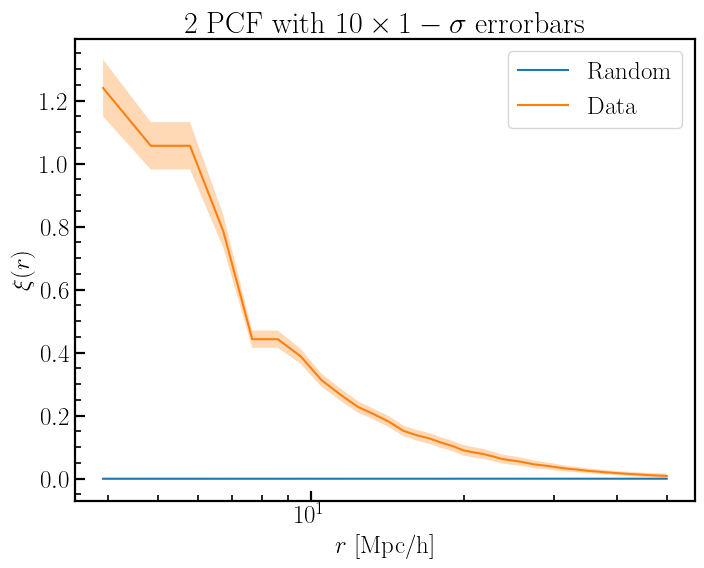

In [38]:
plt.figure(figsize=(8,6))
plt.plot(bins, random_results_mean, label='Random')
plt.plot(bins, results_mean, label='Data')
plt.fill_between(bins, random_results_mean-10*random_results_std, random_results_mean+10*random_results_std, alpha=0.3)
plt.fill_between(bins, results_mean-10*results_std, results_mean+10*results_std, alpha=0.3)
plt.xscale('log')
plt.xlabel(r'$r$ [Mpc/h]')
plt.ylabel(r'$\xi(r)$')
plt.legend()
plt.title(r'$2$ PCF with $10\times 1-\sigma$ errorbars')